# Partition Distribution Analysis

Analyze how Dirichlet partitioning behaves across α and seed for the two FL benchmark tasks.

- **BoolQ**: 50 clients, 2 classes (`super_glue/boolq`)
- **MNLI**:  100 clients, 3 classes (`glue/mnli`, `train` split)
- **α** ∈ {2, 8, ∞}  (∞ = IID)
- **seed** ∈ {42, 123, 456}


## Install dependencies

In [1]:
!pip install -q flwr-datasets datasets matplotlib numpy pandas

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## Imports

In [2]:
from __future__ import annotations

import json
import math
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import DirichletPartitioner, IidPartitioner

warnings.filterwarnings("ignore")

OUT_DIR = Path("./result/data_partition")
OUT_DIR.mkdir(parents=True, exist_ok=True)

/home/ilham/u-flora/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [3]:
@dataclass
class TaskSpec:
    name: str
    hf_path: str
    hf_subset: str | None
    train_split: str
    num_partitions: int
    num_classes: int
    label_names: list[str]

TASKS: dict[str, TaskSpec] = {
    "boolq": TaskSpec(
        name="BoolQ",
        hf_path="super_glue",
        hf_subset="boolq",
        train_split="train",
        num_partitions=50,
        num_classes=2,
        label_names=["false", "true"],
    ),
    "mnli": TaskSpec(
        name="MNLI",
        hf_path="glue",
        hf_subset="mnli",
        train_split="train",
        num_partitions=100,
        num_classes=3,
        label_names=["entailment", "neutral", "contradiction"],
    ),
}

ALPHAS = [2, 8, math.inf]   # inf -> IID
SEEDS  = [42, 123, 456]

def alpha_label(a: float) -> str:
    return "inf" if math.isinf(a) else str(a)

## Partitioning helpers

Mirrors `u_flora/dataset.py::_get_partitioner` — Dirichlet for finite α, IID for α=∞.

In [4]:
def make_partitioner(num_partitions: int, alpha: float, seed: int):
    if math.isinf(alpha):
        # IidPartitioner has no seed kwarg; partitioning is deterministic by index.
        return IidPartitioner(num_partitions=num_partitions)
    return DirichletPartitioner(
        num_partitions=num_partitions,
        partition_by="label",
        alpha=alpha,
        seed=seed,
        min_partition_size=1,   # default 10 rejects α=0.1 draws; we want to *see* the imbalance
        self_balancing=False,   # show the raw Dirichlet draw, not a rebalanced one
    )


def collect_partition_matrix(
    spec: TaskSpec, alpha: float, seed: int
) -> np.ndarray:
    """Return an (num_partitions, num_classes) matrix of class counts."""
    fds = FederatedDataset(
        dataset=spec.hf_path,
        subset=spec.hf_subset,
        partitioners={spec.train_split: make_partitioner(spec.num_partitions, alpha, seed)},
    )
    counts = np.zeros((spec.num_partitions, spec.num_classes), dtype=np.int64)
    for pid in range(spec.num_partitions):
        part = fds.load_partition(pid, spec.train_split)
        labels = np.asarray(part["label"])
        labels = labels[labels >= 0]
        bc = np.bincount(labels, minlength=spec.num_classes)
        counts[pid] = bc[: spec.num_classes]
    return counts

## Quantitative metrics

Per (task, α, seed) configuration we record:

- **size_cv**: coefficient of variation of partition sizes (workload imbalance)
- **size_min / size_max**: smallest and largest partition
- **mean_entropy**: average per-client label entropy (in nats); 0 = single-class clients, ln(K) = uniform
- **mean_entropy_norm**: same, normalized by ln(K) so values lie in [0, 1]
- **mean_js_to_global**: mean Jensen–Shannon divergence between each client's label distribution and the global distribution

In [5]:
def entropy(p: np.ndarray, eps: float = 1e-12) -> float:
    p = p[p > 0]
    return float(-(p * np.log(p + eps)).sum())


def js_divergence(p: np.ndarray, q: np.ndarray, eps: float = 1e-12) -> float:
    p = p + eps; q = q + eps
    p = p / p.sum(); q = q / q.sum()
    m = 0.5 * (p + q)
    def kl(a, b): return float((a * np.log(a / b)).sum())
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)


def summarize(counts: np.ndarray) -> dict:
    sizes = counts.sum(axis=1)
    K = counts.shape[1]
    global_dist = counts.sum(axis=0) / counts.sum()

    nz = sizes > 0
    client_dist = np.zeros_like(counts, dtype=float)
    client_dist[nz] = counts[nz] / sizes[nz, None]

    entropies = np.array([entropy(client_dist[i]) for i in range(counts.shape[0])])
    js = np.array([js_divergence(client_dist[i], global_dist) for i in range(counts.shape[0])])

    return {
        "num_clients":         int(counts.shape[0]),
        "total_examples":      int(counts.sum()),
        "size_min":            int(sizes.min()),
        "size_max":            int(sizes.max()),
        "size_mean":           float(sizes.mean()),
        "size_cv":             float(sizes.std() / max(sizes.mean(), 1e-9)),
        "empty_clients":       int((sizes == 0).sum()),
        "mean_entropy":        float(entropies.mean()),
        "mean_entropy_norm":   float(entropies.mean() / math.log(K)),
        "mean_js_to_global":   float(js.mean()),
        "max_js_to_global":    float(js.max()),
    }

## Run all configurations

Caches the count matrices so we can re-plot without re-partitioning.

In [6]:
matrices: dict[tuple[str, float, int], np.ndarray] = {}
summary_rows: list[dict] = []

for task_key, spec in TASKS.items():
    for alpha in ALPHAS:
        for seed in SEEDS:
            tag = f"{task_key} | α={alpha_label(alpha)} | seed={seed}"
            print(f"→ {tag}")
            counts = collect_partition_matrix(spec, alpha, seed)
            matrices[(task_key, alpha, seed)] = counts

            row = {"task": task_key, "alpha": alpha_label(alpha), "seed": seed}
            row.update(summarize(counts))
            summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df

→ boolq | α=2 | seed=42
→ boolq | α=2 | seed=123
→ boolq | α=2 | seed=456
→ boolq | α=8 | seed=42
→ boolq | α=8 | seed=123
→ boolq | α=8 | seed=456
→ boolq | α=inf | seed=42
→ boolq | α=inf | seed=123
→ boolq | α=inf | seed=456
→ mnli | α=2 | seed=42


Generating test_mismatched split: 100%|██████████| 9847/9847 [00:00<00:00, 1028726.50 examples/s]


→ mnli | α=2 | seed=123
→ mnli | α=2 | seed=456
→ mnli | α=8 | seed=42
→ mnli | α=8 | seed=123
→ mnli | α=8 | seed=456
→ mnli | α=inf | seed=42
→ mnli | α=inf | seed=123
→ mnli | α=inf | seed=456


,task,alpha,seed,num_clients,total_examples,size_min,size_max,size_mean,size_cv,empty_clients,mean_entropy,mean_entropy_norm,mean_js_to_global,max_js_to_global
0,boolq,2,42,50,9427,34,452,188.54,0.537688,0,0.604709,0.872411,0.019412,0.102552
1,boolq,2,123,50,9427,65,454,188.54,0.441438,0,0.593761,0.856616,0.019171,0.112526
2,boolq,2,456,50,9427,49,551,188.54,0.572049,0,0.561645,0.810282,0.034666,0.170856
3,boolq,8,42,50,9427,96,305,188.54,0.265122,0,0.646530,0.932745,0.004971,0.028390
4,boolq,8,123,50,9427,121,307,188.54,0.214218,0,0.643862,0.928896,0.004980,0.035326
5,boolq,8,456,50,9427,100,347,188.54,0.290676,0,0.641038,0.924823,0.007571,0.030789
6,boolq,inf,42,50,9427,188,189,188.54,0.002643,0,0.659859,0.951975,0.000673,0.004702
7,boolq,inf,123,50,9427,188,189,188.54,0.002643,0,0.659859,0.951975,0.000673,0.004702
8,boolq,inf,456,50,9427,188,189,188.54,0.002643,0,0.659859,0.951975,0.000673,0.004702
9,mnli,2,42,100,392702,832,8113,3927.02,0.396953,0,0.959735,0.873589,0.036633,0.141676


## Aggregate table (mean across seeds)

In [7]:
agg_cols = ["size_cv", "size_min", "size_max", "mean_entropy_norm", "mean_js_to_global", "empty_clients"]
agg = (
    summary_df.groupby(["task", "alpha"])[agg_cols]
    .agg(["mean", "std"])
    .round(4)
)
agg

size_cv           size_min             size_max            \
               mean     std       mean       std       mean       std   
task  alpha                                                             
boolq 2      0.5171  0.0677    49.3333   15.5027   485.6667   56.5892   
      8      0.2567  0.0389   105.6667   13.4288   319.6667   23.6925   
      inf    0.0026  0.0000   188.0000    0.0000   189.0000    0.0000   
mnli  2      0.3952  0.0247   934.0000  128.2653  8155.3333  631.5650   
      8      0.2059  0.0038  2101.3333  315.1529  6440.6667  106.2136   
      inf    0.0000  0.0000  3927.0000    0.0000  3928.0000    0.0000   

            mean_entropy_norm         mean_js_to_global         empty_clients  \
                         mean     std              mean     std          mean   
task  alpha                                                                     
boolq 2                0.8464  0.0323            0.0244  0.0089           0.0   
      8                0.9288  0.0040            0.0058  0.0015           0.0   
      inf              0.9520  0.0000            0.0007  0.0000           0.0   
mnli  2                0.8619  0.0143            0.0400  0.0041           0.0   
      8                0.9637  0.0049            0.0102  0.0014           0.0   
      inf              0.9998  0.0000            0.0001  0.0000           0.0   

                  
             std  
task  alpha       
boolq 2      0.0  
      8      0.0  
      inf    0.0  
mnli  2      0.0  
      8      0.0  
      inf    0.0

## Visualization 1 — Per-client class proportions (stacked bars)

Each subplot is one (α, seed). Within a subplot, the x-axis is `client_id` sorted by majority-class share so heterogeneity is visually obvious. IID (α=∞) should look uniform; small α should show extreme spikes.

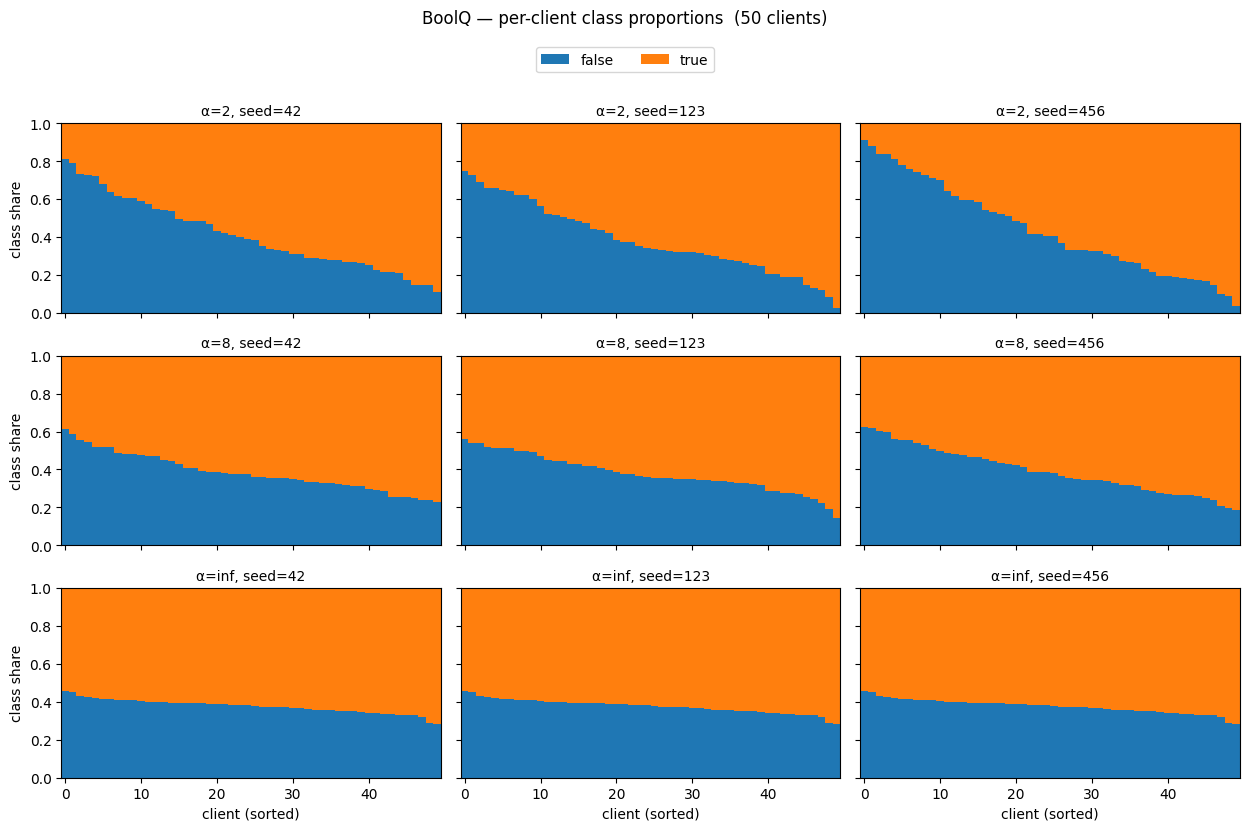

saved: result/data_partition/stacked_boolq.png


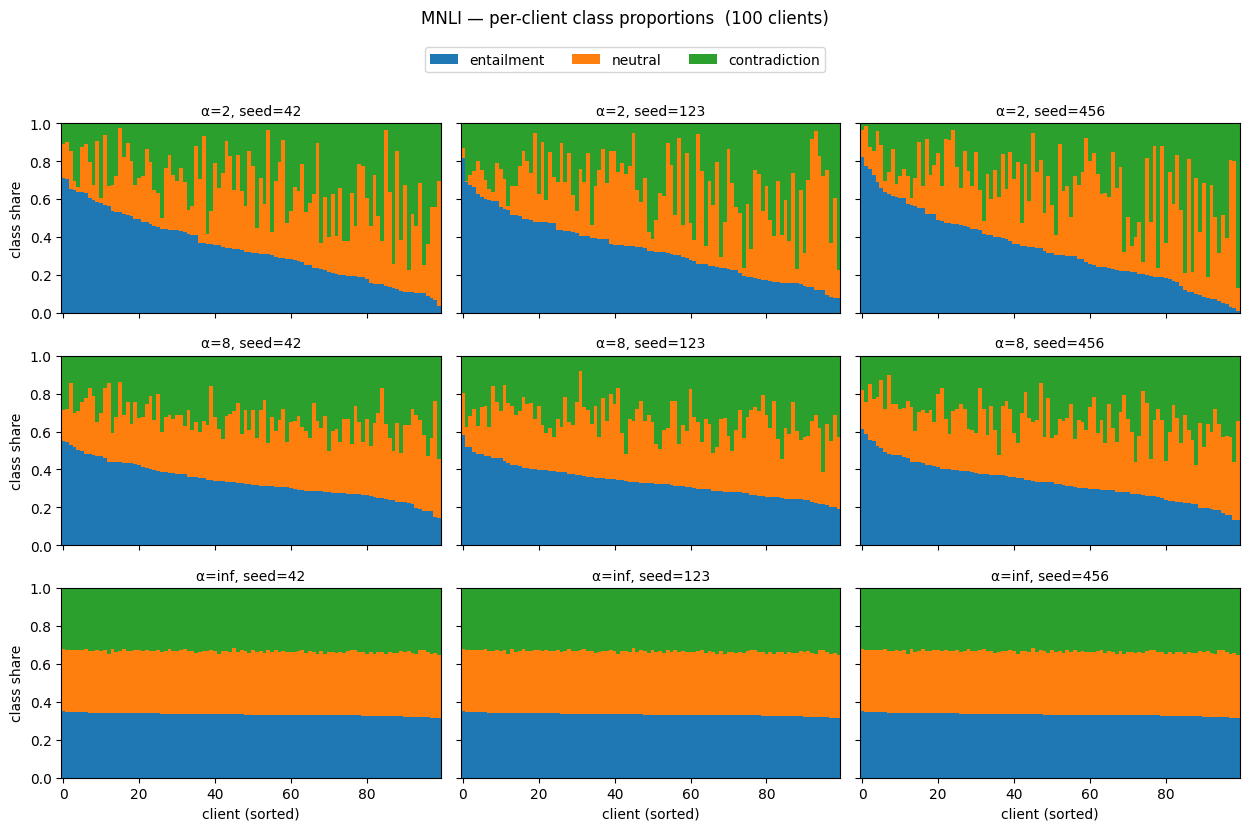

saved: result/data_partition/stacked_mnli.png


In [8]:
def plot_stacked(task_key: str):
    spec = TASKS[task_key]
    fig, axes = plt.subplots(
        len(ALPHAS), len(SEEDS),
        figsize=(4.2 * len(SEEDS), 2.6 * len(ALPHAS)),
        sharex=True, sharey=True,
    )
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i) for i in range(spec.num_classes)]

    for i, alpha in enumerate(ALPHAS):
        for j, seed in enumerate(SEEDS):
            ax = axes[i, j]
            counts = matrices[(task_key, alpha, seed)]
            sizes = counts.sum(axis=1, keepdims=True).clip(min=1)
            props = counts / sizes
            order = np.argsort(-props[:, 0])
            props = props[order]

            x = np.arange(props.shape[0])
            bottom = np.zeros(props.shape[0])
            for c in range(spec.num_classes):
                ax.bar(
                    x, props[:, c], bottom=bottom,
                    color=colors[c], width=1.0,
                    label=spec.label_names[c] if (i == 0 and j == 0) else None,
                )
                bottom += props[:, c]

            ax.set_title(f"α={alpha_label(alpha)}, seed={seed}", fontsize=10)
            ax.set_ylim(0, 1)
            ax.set_xlim(-0.5, spec.num_partitions - 0.5)
            if j == 0:
                ax.set_ylabel("class share")
            if i == len(ALPHAS) - 1:
                ax.set_xlabel("client (sorted)")

    fig.legend(loc="upper center", ncol=spec.num_classes, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(f"{spec.name} — per-client class proportions  ({spec.num_partitions} clients)", y=1.06, fontsize=12)
    plt.tight_layout()
    out = OUT_DIR / f"stacked_{task_key}.png"
    # plt.savefig(out, dpi=140, bbox_inches="tight")
    plt.show()
    print(f"saved: {out}")

plot_stacked("boolq")
plot_stacked("mnli")

## Visualization 2 — Partition size distribution

Workload imbalance independent of label skew. Small α produces a few large + many tiny partitions.

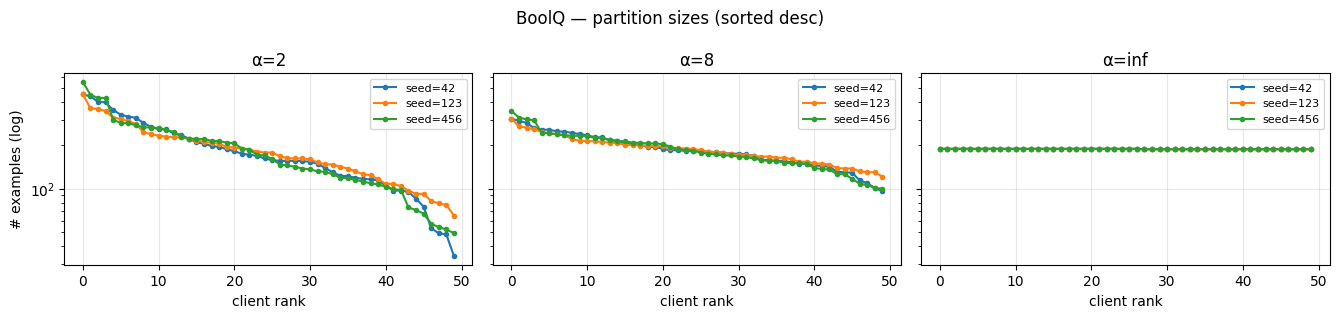

saved: result/data_partition/sizes_boolq.png


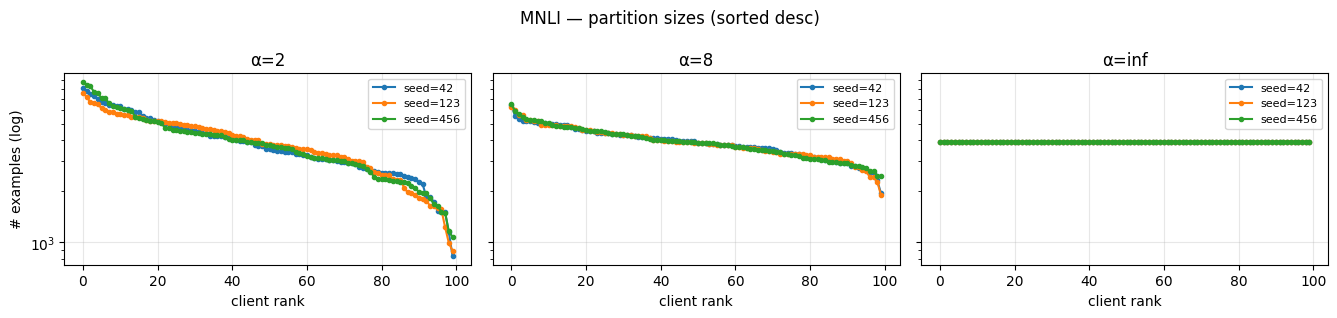

saved: result/data_partition/sizes_mnli.png


In [9]:
def plot_sizes(task_key: str):
    spec = TASKS[task_key]
    fig, axes = plt.subplots(1, len(ALPHAS), figsize=(4.5 * len(ALPHAS), 3.2), sharey=True)
    for i, alpha in enumerate(ALPHAS):
        ax = axes[i]
        for seed in SEEDS:
            sizes = matrices[(task_key, alpha, seed)].sum(axis=1)
            sizes_sorted = np.sort(sizes)[::-1]
            ax.plot(np.arange(len(sizes_sorted)), sizes_sorted,
                    marker="o", ms=3, label=f"seed={seed}")
        ax.set_title(f"α={alpha_label(alpha)}")
        ax.set_xlabel("client rank")
        ax.grid(True, alpha=0.3)
        ax.set_yscale("log")
        if i == 0:
            ax.set_ylabel("# examples (log)")
        ax.legend(fontsize=8)
    fig.suptitle(f"{spec.name} — partition sizes (sorted desc)", fontsize=12)
    plt.tight_layout()
    out = OUT_DIR / f"sizes_{task_key}.png"
    # plt.savefig(out, dpi=140, bbox_inches="tight")
    plt.show()
    print(f"saved: {out}")

plot_sizes("boolq")
plot_sizes("mnli")

## Visualization 3 — Heterogeneity metrics across α

Bars are seed means; error bars are min/max across the three seeds — shows seed-to-seed variability of each α regime.

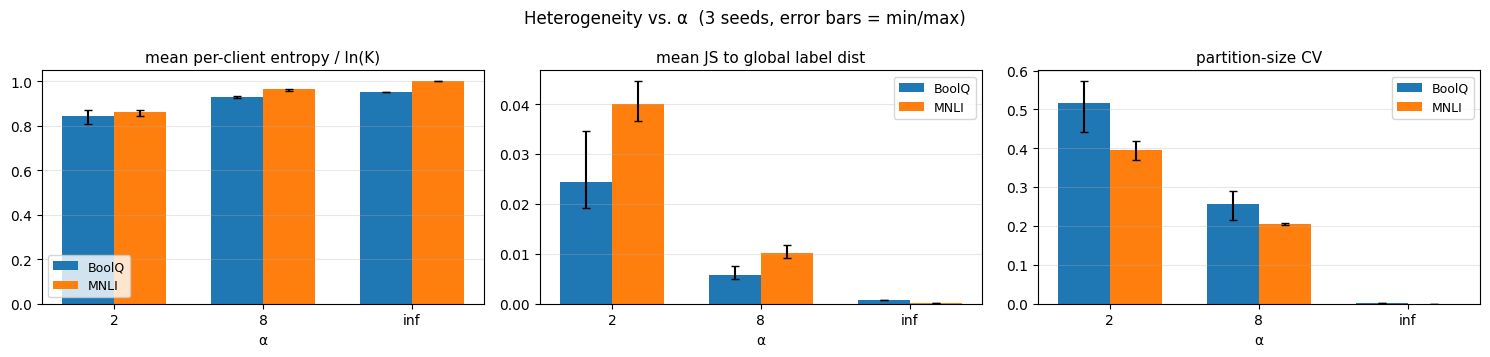

saved: result/data_partition/metrics_vs_alpha.png


In [10]:
def plot_metric_bars():
    metrics = [
        ("mean_entropy_norm", "mean per-client entropy / ln(K)"),
        ("mean_js_to_global", "mean JS to global label dist"),
        ("size_cv",           "partition-size CV"),
    ]
    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 3.6))
    width = 0.35
    x = np.arange(len(ALPHAS))

    for ax, (col, title) in zip(axes, metrics):
        for k, task_key in enumerate(TASKS):
            sub = summary_df[summary_df.task == task_key]
            means = [sub[sub.alpha == alpha_label(a)][col].mean() for a in ALPHAS]
            mins  = [sub[sub.alpha == alpha_label(a)][col].min()  for a in ALPHAS]
            maxs  = [sub[sub.alpha == alpha_label(a)][col].max()  for a in ALPHAS]
            err = np.array([
                [m - mn for m, mn in zip(means, mins)],
                [mx - m for m, mx in zip(means, maxs)],
            ])
            ax.bar(x + (k - 0.5) * width, means, width=width,
                   yerr=err, capsize=3, label=TASKS[task_key].name)
        ax.set_xticks(x)
        ax.set_xticklabels([alpha_label(a) for a in ALPHAS])
        ax.set_xlabel("α")
        ax.set_title(title, fontsize=11)
        ax.grid(True, axis="y", alpha=0.3)
        ax.legend(fontsize=9)
    fig.suptitle("Heterogeneity vs. α  (3 seeds, error bars = min/max)", fontsize=12)
    plt.tight_layout()
    out = OUT_DIR / "metrics_vs_alpha.png"
    # plt.savefig(out, dpi=140, bbox_inches="tight")
    plt.show()
    print(f"saved: {out}")

plot_metric_bars()

## Save summary

In [11]:
# csv_path  = OUT_DIR / "partition_summary.csv"
# json_path = OUT_DIR / "partition_summary.json"
# summary_df.to_csv(csv_path, index=False)
# json_path.write_text(json.dumps(summary_rows, indent=2))
# print(f"saved: {csv_path}")
# print(f"saved: {json_path}")

# np_path = OUT_DIR / "partition_counts.npz"
# np.savez(
#     np_path,
#     **{f"{t}__a{alpha_label(a)}__s{s}": m for (t, a, s), m in matrices.items()},
# )
# print(f"saved: {np_path}")

## Interpretation guide

- **α = 2** → high label skew: many clients are near-single-class, `mean_entropy_norm` is low, `mean_js_to_global` is high, partition sizes are wildly uneven (`size_cv` large, possibly empty clients).
- **α = 8** → moderate skew: the standard FL benchmark setting. Each client sees most classes but with non-uniform proportions.
- **α = ∞** → IID: `mean_entropy_norm ≈ 1`, `mean_js_to_global ≈ 0`, `size_cv` only reflects integer-rounding.

Seed variance is highest at α=0.1 — this is why the FL benchmark sweeps three seeds rather than one.